# The ramen index — a quantitative teardown 🔬
### Lead-lag cross-correlation (does demand *precede* the market?) · bull/bear beta · Newey-West CAPM alpha vs the Nikkei · the recession-window paired *t* · the double look-ahead that kills the trade · planted-lead & planted-defensive positive controls

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![A leading tell%3F: Busted](https://img.shields.io/badge/A_leading_tell%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We test the strongest form of "the ramen index is a downturn tell" on the WINA world-demand series and on `2897.T` (Nissin) / `2875.T` (Toyo Suisan) vs `^N225`: (H₁) **demand leads** — a negative lead-lag correlation at a positive lead with *t* > 2; (H₂) **recession outperformance** — positive recession-window excess with *t* > 2; (H₃) it is **investable** net of the WINA + NBER publication lags. We find **H₁ rejected** (best lead *t* = −1.05; demand grows the same in/out of recessions), **H₂ rejected** (no leg clears *t* = 2), **H₃ rejected** (a double look-ahead). A significant CAPM α vs the Nikkei **does** appear — and we show why it is a survivorship + weak-benchmark artefact, not the tell.

> ⚠️ **Not investment advice — data provenance.** `2897.T`, `2875.T`, `^N225` are month-end Adj Close via yfinance (as-of 2026-06-30; split+dividend adjusted). The **ramen index** is the WINA world-demand series and the NBER windows are **hardcoded, cited** (labelled facts, not a feed). Offline core + synthetic controls are deterministic. Methods in [`docs/references.md`](../docs/references.md); numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"
NOOD = "#d97b29"   # a ramen-broth orange for the noodle series

from ramen_recession import data, strategy as st

HAVE_PRICES = data.have_prices()
PX = data.load_prices() if HAVE_PRICES else None
RI = data.load_ramen_index()        # WINA demand (hardcoded, cited) — always available
print("price cache present:", HAVE_PRICES,
      "| ramen index", RI.index[0].year, "->", RI.index[-1].year,
      "| NBER recessions:", [r[0] for r in data.NBER_RECESSIONS])

# frozen headline numbers (mirror of docs/results.md)
R = {'win': '2001 → 2026', 'n_stock': 305, 'n_n225': 317, 'll_leads': [-2, -1, 0, 1, 2], 'll_r': [-0.34, 0.31, 0.12, -0.25, -0.03], 'll_t': [-1.51, 1.32, 0.51, -1.05, -0.12], 'll_best_lead': 1, 'll_best_r': -0.25, 'll_best_t': -1.05, 'll_best_p': 0.31, 'll_n': 19, 'dem_in': 2.02, 'dem_out': 1.93, 'dem_diff': 0.09, 'dem_t': 0.02, 'dem_p': 0.98, 'dem_nin': 4, 'dem_nout': 15, 'ri_2005': 85.7, 'ri_2024': 122.0, 'ri_cagr': 1.88, 'dem_2008': -4.2, 'dem_2009': -3.8, 'dem_2020': 9.6, 'dem_2014': -2.7, 'dem_2015': -4.9, 'nis_cagr': 6.14, 'nis_vol': 20.2, 'nis_sharpe': 0.4, 'nis_mdd': -42.7, 'nis_wealth': 4.54, 'toy_cagr': 11.53, 'toy_vol': 25.8, 'toy_sharpe': 0.55, 'toy_mdd': -36.6, 'toy_wealth': 16.02, 'n225_cagr': 4.95, 'n225_vol': 19.2, 'n225_sharpe': 0.35, 'n225_mdd': -62.8, 'n225_wealth': 3.59, 'hold_yrs': 25.4, 'nis_alpha': 6.54, 'nis_beta': 0.2, 'nis_t': 2.03, 'nis_p': 0.044, 'toy_alpha': 12.2, 'toy_beta': 0.31, 'toy_t': 2.79, 'toy_p': 0.006, 'nis_down_beta': 0.47, 'nis_up_beta': -0.05, 'nis_asym': 0.52, 'nis_def': 0, 'toy_down_beta': 0.14, 'toy_up_beta': 0.27, 'toy_asym': -0.13, 'toy_def': 1, 'n_down': 130, 'n_up': 175, 'rec_n': 31, 'nis_rec_mean': -0.6, 'nis_rec_excess': 1.55, 'nis_rec_t': 0.94, 'nis_rec_p': 0.352, 'nis_rec_cum': -25.0, 'toy_rec_mean': 1.37, 'toy_rec_excess': 3.53, 'toy_rec_t': 1.34, 'toy_rec_p': 0.189, 'toy_rec_cum': 17.0, 'n225_rec_mean': -2.15, 'n225_rec_cum': -54.1, 'rec_labels': ['2001 dot-com', '2008 GFC', '2020 COVID'], 'nis_by_rec': [-7.5, -24.6, 7.6], 'toy_by_rec': [6.9, -3.1, 13.0], 'n225_by_rec': [-17.0, -36.5, -13.0], 'wina_lag': 6, 'nber_lag': 12, 'syn_lead': 1, 'syn_lead_r': -0.93, 'syn_lead_t': -15.1, 'syn_down': 0.71, 'syn_up': 0.98, 'syn_plant_down': 0.5, 'syn_plant_up': 1.0}


price cache present: True | ramen index 2005 -> 2024 | NBER recessions: ['2001 dot-com', '2008 GFC', '2020 COVID']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | The tell fails: best lead-lag *t* = **-1.05** (lead +1y), demand in-vs-out recession *t* = **+0.02**, recession-window excess *t* = **+0.94** / **+1.34**. |
| **Tradability** | `MIRAGE` | Double look-ahead: WINA ~6 mo + NBER ~12 mo late. The only market-beating item (α vs Nikkei) is survivorship. |
| **A leading tell?** | `BUSTED` | Demand **fell** in the 2008 GFC (-4.2%, -3.8%) and in 2014–2016; the only spike was COVID-2020 (+9.6%). Secular Asian growth, not a cycle instrument. |

> 💡 In plain words: the ramen index carries no cycle information — it doesn't lead downturns and doesn't even reliably rise in them. The noodle *stocks* did beat a moribund Nikkei, but that is the low-beta staple premium on two hand-picked survivors, not the recession tell the folklore sells.

## 1 · The claim, steelmanned

Let $d_t$ be the ramen index's YoY demand growth in year $t$ and $r^M_t$ the market's annual return. The folklore is a joint hypothesis:

- **H₁ (demand leads).** For some lead $k \ge 1$, $\;\rho(d_t, r^M_{t+k}) < 0$ with $|t| > 2$: high noodle-demand growth today precedes a *weak* market $k$ years out. (Equivalently, demand growth is higher in recession years.)
- **H₂ (recession outperformance).** Over NBER recession months $\mathcal{R}$, each noodle stock's mean excess $\;\bar{x}=\text{mean}_{t\in\mathcal{R}}(r^P_t-r^M_t)$ is positive with $t>2$.
- **H₃ (investable).** After the WINA release lag (~6 mo) and the NBER announcement lag (~12 mo), a ramen-conditional rule beats simply holding the index.

The steelman is textbook: instant noodles are a canonical **inferior good**, so demand *should* be income-elastic in the wrong direction — up when incomes fall. The test is whether that shows up in the **aggregate demand series**, **ahead of** the cycle, in a way you could **act on** — or only in a 2008 US anecdote and one COVID spike.

## 2 · So what? — what rides on each answer

If H₁–H₃ held, the ramen index would be a genuine leading indicator (H₁) *and* the noodle makers a recession hedge (H₂) you could actually implement (H₃). Each leg is separately falsifiable. H₁ is a **lead-lag** statement on an annual macro series — low-frequency, tiny-sample, so we announce the bar (a *negative* correlation at a *positive* lead, |t|>2) before looking. H₂ is the **event-study** on three recessions (31 months) — fragile to one idiosyncratic window. H₃ is the **realisability** check: the demand figure is published with a lag *and* the recession is dated with a lag, so any ramen-conditional strategy is a double look-ahead. The claim needs all three; failing H₁ alone already reduces "the ramen index" to a coincidence museum.

## 3 · How we'd know — the protocol

- **Data.** `2897.T`, `2875.T`, `^N225` month-end Adj Close (yfinance, cached; splits + dividends folded in — *total-return-ish*). Sample 2001-01 → 2026-06 (noodle names n=305 monthly returns; `^N225` from 2000, n=317). The **ramen index** = WINA world demand, 2005–2024 (19 growth observations), **hardcoded, cited, approximate** — a labelled proxy.
- **Survivorship — named on the Signal axis.** These are the two *surviving* noodle champions, selected ex-post; the bias points **for** the outperformance/defensiveness claim, so any positive result (notably the §4d alpha) is treated as suspect and explicitly quarantined from the Signal verdict.
- **H₁ test.** Lead-lag Pearson correlation $\rho(d_t, r^M_{t+k})$ for $k\in\{-2..+2\}$ with a small-sample $t=r\sqrt{(n-2)/(1-r^2)}$; plus a Welch *t* of demand growth in vs out of recession years. `REAL` needs a negative, significant lead at $k\ge1$.
- **H₂ test.** Paired *t* of the recession-window monthly excess $r^P-r^M$ over the union of NBER recession months; a per-recession breakdown checks it isn't one window.
- **Bull/bear beta & CAPM α.** Conditional betas (split at $r^M=0$) and a Newey-West (6-lag) HAC *t* of the full-sample alpha vs `^N225`.
- **H₃ / cost (beat 6).** The WINA + NBER publication lags (the double look-ahead) and the full-sample terminal-wealth comparison.
- **Positive controls.** (a) A deterministic index engineered to *lead* the market by 1 year — the cross-correlation engine must recover it; (b) a planted asymmetric-beta stock — the bull/bear engine must recover it. Machinery proofs, never market evidence.
- **What would make us say "real tell":** a negative lead-lag *t* < −2 at $k\ge1$ **and** a recession-window *t* > 2. We find neither.

## 4 · The teardown

### 4a · H₁ — does demand *lead*? (the headline)

Cross-correlation of WINA demand growth $d_t$ against the Nikkei's annual return $r^M_{t+k}$. A real tell lives in the **negative, positive-lead** quadrant.

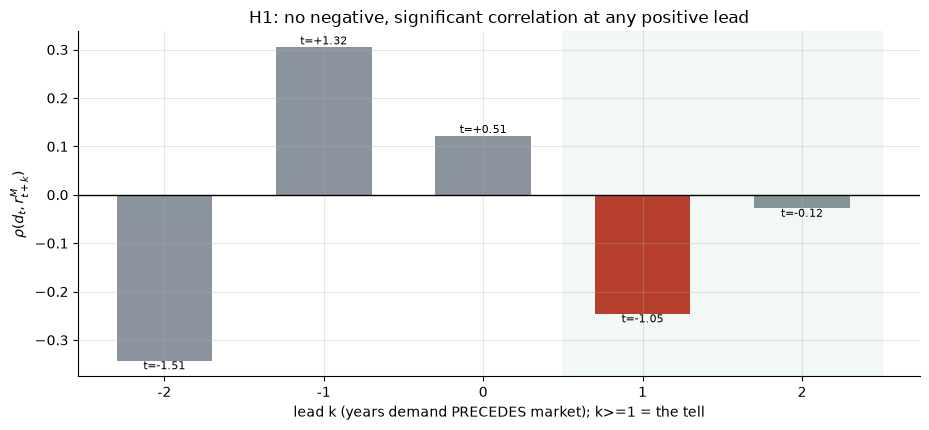

lead-lag:
  k=-2: r=-0.34  t=-1.51
  k=-1: r=+0.31  t=+1.32
  k=+0: r=+0.12  t=+0.51
  k=+1: r=-0.25  t=-1.05
  k=+2: r=-0.03  t=-0.12
demand growth: recession yrs +2.02%  vs other +1.93%  diff +0.09  t=+0.02


In [2]:
if HAVE_PRICES:
    mkt = PX['^N225'].resample('YE').last().pct_change().dropna()
    ll = st.lead_lag_corr(data.ramen_growth()/100.0, mkt, leads=range(-2,3))
    leads=list(ll['per_lead']); rs=[ll['per_lead'][k]['r'] for k in leads]; ts=[ll['per_lead'][k]['t'] for k in leads]
    dv = st.demand_in_vs_out_recession(data.ramen_growth(), data.recession_years())
else:
    leads, rs, ts = R['ll_leads'], R['ll_r'], R['ll_t']
    dv = dict(in_mean=R['dem_in'], out_mean=R['dem_out'], diff=R['dem_diff'], t=R['dem_t'], p=R['dem_p'])
fig, ax = plt.subplots(figsize=(9.4, 4.4))
cols=[RED if k==R['ll_best_lead'] else GREY for k in leads]
ax.bar([str(k) for k in leads], rs, .6, color=cols)
ax.axhline(0,c='k',lw=1); ax.axvspan(2.5,4.5,color=GREEN,alpha=.06)
ax.set_xlabel('lead k (years demand PRECEDES market); k>=1 = the tell'); ax.set_ylabel(r'$\rho(d_t, r^M_{t+k})$')
for i,k in enumerate(leads): ax.annotate(f't={ts[i]:+.2f}',(i,rs[i]),ha='center',va='bottom' if rs[i]>=0 else 'top',fontsize=8)
ax.set_title('H1: no negative, significant correlation at any positive lead'); plt.tight_layout(); plt.show()
print('lead-lag:'); [print(f'  k={k:+d}: r={rs[i]:+.2f}  t={ts[i]:+.2f}') for i,k in enumerate(leads)]
print(f"demand growth: recession yrs {dv['in_mean']:+.2f}%  vs other {dv['out_mean']:+.2f}%  diff {dv['diff']:+.2f}  t={dv['t']:+.2f}")

> 💡 In plain words: the "tell" lead (+1y) is *r* = -0.25, *t* = -1.05 — a coin flip. The largest |correlation| sits at lead **−2** (*t* = -1.51), i.e. the market moving *before* the noodles if anything — the opposite of leading. And demand grows **+2.0%/yr** in recession years vs **+1.9%** otherwise (*t* = +0.02). H₁ rejected: the ramen index carries no cycle information.

### 4b · H₂ — recession-window returns (the stocks as a hedge)

Paired excess $r^P-r^M$ over the union of NBER recession months, with the per-recession breakdown that shows whether any aggregate edge is broad or one window.

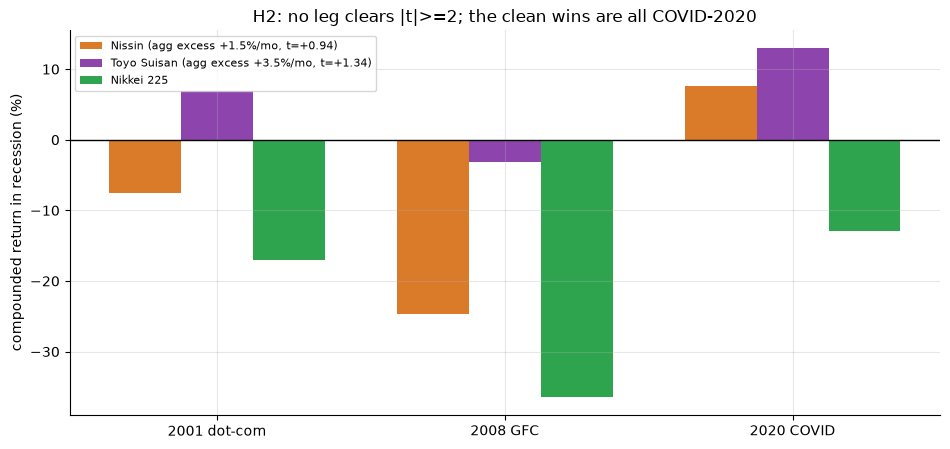

2001 dot-com    Nissin   -7.5%  Toyo   +6.9%  Nikkei  -17.0%
2008 GFC        Nissin  -24.6%  Toyo   -3.1%  Nikkei  -36.5%
2020 COVID      Nissin   +7.6%  Toyo  +13.0%  Nikkei  -13.0%
aggregate excess: Nissin t=+0.94  Toyo t=+1.34  (bar is |t|>=2)


In [3]:
labels=R['rec_labels']
if HAVE_PRICES:
    br=PX['^N225'].pct_change().dropna()
    nre=st.recession_excess_t(PX['2897.T'].pct_change().dropna(), br, data.recession_mask)
    tre=st.recession_excess_t(PX['2875.T'].pct_change().dropna(), br, data.recession_mask)
    nb=st.recession_breakdown(PX['2897.T'].pct_change().dropna(), br, data.NBER_RECESSIONS)
    tb=st.recession_breakdown(PX['2875.T'].pct_change().dropna(), br, data.NBER_RECESSIONS)
    nisv=[nb[l]['stock']*100 for l in labels]; toyv=[tb[l]['stock']*100 for l in labels]; benv=[nb[l]['bench']*100 for l in labels]
    nt,tt=nre['t'],tre['t']; nex,tex=nre['mean_excess']*100,tre['mean_excess']*100
else:
    nisv,toyv,benv=R['nis_by_rec'],R['toy_by_rec'],R['n225_by_rec']
    nt,tt,nex,tex=R['nis_rec_t'],R['toy_rec_t'],R['nis_rec_excess'],R['toy_rec_excess']
x=np.arange(3); fig, ax = plt.subplots(figsize=(9.6, 4.6))
ax.bar(x-.25, nisv, .25, color=NOOD, label=f'Nissin (agg excess {nex:+.1f}%/mo, t={nt:+.2f})')
ax.bar(x,      toyv, .25, color='#8e44ad', label=f'Toyo Suisan (agg excess {tex:+.1f}%/mo, t={tt:+.2f})')
ax.bar(x+.25, benv, .25, color=GREEN, label='Nikkei 225')
ax.axhline(0,c='k',lw=1); ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel('compounded return in recession (%)'); ax.set_title('H2: no leg clears |t|>=2; the clean wins are all COVID-2020'); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
for i,l in enumerate(labels): print(f'{l:14s}  Nissin {nisv[i]:+6.1f}%  Toyo {toyv[i]:+6.1f}%  Nikkei {benv[i]:+6.1f}%')
print(f'aggregate excess: Nissin t={nt:+.2f}  Toyo t={tt:+.2f}  (bar is |t|>=2)')

> 💡 In plain words: Nissin's recession excess is *t* = +0.94, Toyo Suisan's *t* = +1.34 — neither clears the bar. Both *fell* in the 2008 GFC (−24.6% / −3.1%), just less than the Nikkei's −36.5%; the unambiguous wins (2020 +7.6% / +13.0%) are the COVID pantry-loading window. "Falls less than a collapsing index" is low beta, not counter-cyclicality. H₂ rejected.

### 4c · Bull vs bear beta — is it even defensive?

Conditional OLS slope on `^N225`, split by the sign of the market return. Defensive requires $\beta^- < \beta^+ < 1$.

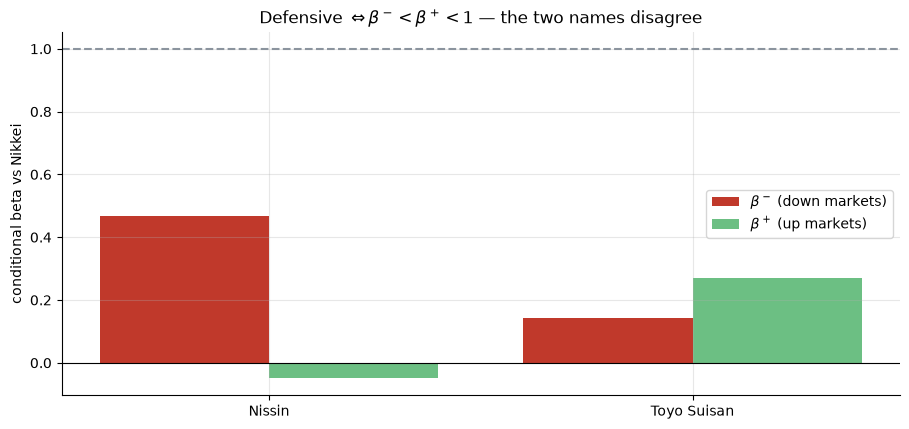

2897.T: down-beta +0.47  up-beta -0.05  full 0.20  asym +0.52  defensive=0
2875.T: down-beta +0.14  up-beta +0.27  full 0.31  asym -0.13  defensive=1


In [4]:
if HAVE_PRICES: br = PX['^N225'].pct_change().dropna()
rows={}
for t,pre in [('2897.T','nis'),('2875.T','toy')]:
    if HAVE_PRICES:
        bb=st.bull_bear_beta(PX[t].pct_change().dropna(), br, split=0.0)
        rows[t]=dict(d=bb['down_beta'],u=bb['up_beta'],f=bb['full_beta'],a=bb['asymmetry'],defn=bb['defensive'])
    else:
        rows[t]=dict(d=R[f'{pre}_down_beta'],u=R[f'{pre}_up_beta'],f=R[f'{pre}_beta'],a=R[f'{pre}_asym'],defn=R[f'{pre}_def'])
x=np.arange(2); fig, ax = plt.subplots(figsize=(9.2, 4.4)); ks=list(rows)
ax.bar(x-.2, [rows[t]['d'] for t in ks], .4, color=RED, label=r'$\beta^-$ (down markets)')
ax.bar(x+.2, [rows[t]['u'] for t in ks], .4, color=GREEN, alpha=.7, label=r'$\beta^+$ (up markets)')
ax.axhline(1.0, ls='--', c=GREY); ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels(['Nissin','Toyo Suisan'])
ax.set_ylabel('conditional beta vs Nikkei'); ax.set_title(r'Defensive $\Leftrightarrow \beta^-<\beta^+<1$ — the two names disagree'); ax.legend()
plt.tight_layout(); plt.show()
for t in ks: r=rows[t]; print(f"{t}: down-beta {r['d']:+.2f}  up-beta {r['u']:+.2f}  full {r['f']:.2f}  asym {r['a']:+.2f}  defensive={r['defn']}")

> 💡 In plain words: same split as the sibling beer study. Nissin loads *more* on the downside ($\beta^-$=0.47 > $\beta^+$=-0.05, asymmetry +0.52) — the opposite of defensive; Toyo Suisan is weakly defensive ($\beta^-$=0.14 < $\beta^+$=0.27). Both full betas are ≈0.2–0.3: these are simply very low-beta stocks, which is not counter-cyclicality.

### 4d · CAPM α vs the Nikkei — the honest complication

Newey-West (6-lag) HAC regression of each name on `^N225`. This is the one place a significant number appears — so we handle it carefully.

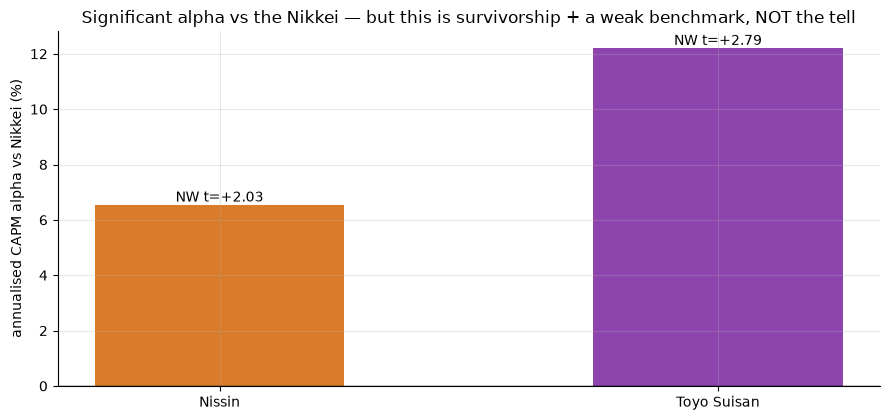

2897.T: CAGR  6.14%  vol 20.2%  Sharpe 0.40  maxDD  -42.7%  |  alpha +6.54%/yr  beta 0.20  NW t +2.03
2875.T: CAGR 11.53%  vol 25.8%  Sharpe 0.55  maxDD  -36.6%  |  alpha +12.20%/yr  beta 0.31  NW t +2.79


In [5]:
rows={}
for t,pre in [('2897.T','nis'),('2875.T','toy')]:
    if HAVE_PRICES:
        nw=st.newey_west_alpha_t(PX[t].pct_change().dropna(), br, 6); s=st.summarize(PX[t])
        rows[t]=dict(alpha=nw['alpha_ann']*100, beta=nw['beta'], tt=nw['t_alpha'], cagr=s['cagr']*100, vol=s['vol']*100, sharpe=s['sharpe'], mdd=s['mdd']*100)
    else:
        rows[t]=dict(alpha=R[f'{pre}_alpha'], beta=R[f'{pre}_beta'], tt=R[f'{pre}_t'], cagr=R[f'{pre}_cagr'], vol=R[f'{pre}_vol'], sharpe=R[f'{pre}_sharpe'], mdd=R[f'{pre}_mdd'])
ks=list(rows); alphas=[rows[t]['alpha'] for t in ks]; ts=[rows[t]['tt'] for t in ks]
fig, ax = plt.subplots(figsize=(9.0, 4.3)); ax.bar(['Nissin','Toyo Suisan'], alphas, .5, color=[NOOD,'#8e44ad'])
ax.axhline(0,c='k',lw=1); ax.set_ylabel('annualised CAPM alpha vs Nikkei (%)')
for i,t in enumerate(ks): ax.annotate(f'NW t={ts[i]:+.2f}',(i,alphas[i]),ha='center',va='bottom')
ax.set_title('Significant alpha vs the Nikkei — but this is survivorship + a weak benchmark, NOT the tell')
plt.tight_layout(); plt.show()
for t in ks: r=rows[t]; print(f"{t}: CAGR {r['cagr']:5.2f}%  vol {r['vol']:4.1f}%  Sharpe {r['sharpe']:.2f}  maxDD {r['mdd']:6.1f}%  |  alpha {r['alpha']:+.2f}%/yr  beta {r['beta']:.2f}  NW t {r['tt']:+.2f}")

> 💡 In plain words: both alphas *do* clear the bar (NW *t* = +2.03 / +2.79) — and it would be dishonest to hide that under a `NONE` stamp. But it is **not the claim**. Three reasons it is not evidence for a ramen *tell*: (1) it is about *beating the Nikkei*, not *leading recessions* — §4a already killed the timing; (2) **survivorship** — we hand-picked two surviving noodle champions, which manufactures outperformance; (3) β≈0.20–0.31 against an index that returned ~5%/yr through Japan's lost decades is the **low-vol / quality premium**, freely available. Real number, wrong claim — the Signal axis tracks *the tell*, which is absent.

### 4e · Positive controls — the engines are faithful

Two machinery proofs (never market evidence): an index engineered to *lead* the market by 1 year, and a stock with a planted asymmetric (defensive) beta.

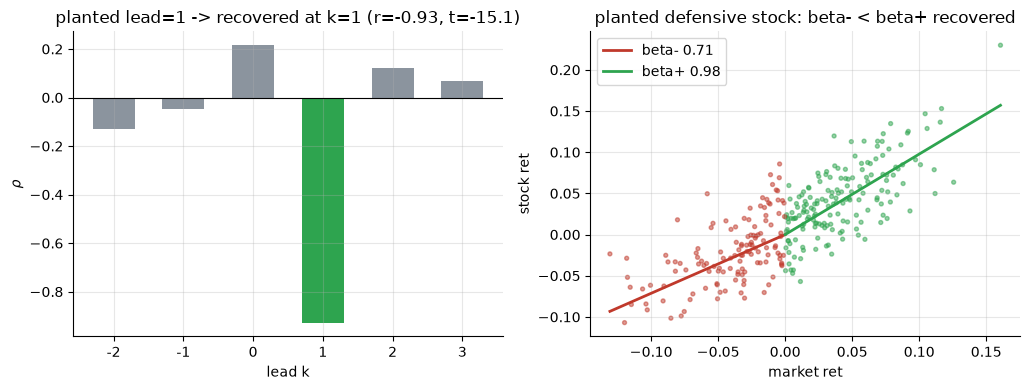

lead control: planted 1 -> best_lead 1 r=-0.93 t=-15.1 ok=1
defensive control: planted 0.50/1.00 -> recovered 0.71/0.98 defensive=1


In [6]:
ig, mk = data.synthetic_leading_index(lead=1, seed=729)
cl = st.control_recovers_lead(ig, mk, planted_lead=1)
mkt2, stock2 = data.synthetic_defensive(beta_down=0.5, beta_up=1.0, seed=7290)
cd = st.control_recovers_defensive(stock2, mkt2, 0.5, 1.0)
ll = st.lead_lag_corr(ig, mk, leads=range(-2,4))
leads=list(ll['per_lead']); rs=[ll['per_lead'][k]['r'] for k in leads]
fig, (a1,a2) = plt.subplots(1,2, figsize=(10.4,4.0))
a1.bar([str(k) for k in leads], rs, .6, color=[GREEN if k==1 else GREY for k in leads]); a1.axhline(0,c='k',lw=.8)
a1.set_title(f'planted lead=1 -> recovered at k={cl["best_lead"]} (r={cl["best_r"]:.2f}, t={cl["best_t"]:.1f})'); a1.set_xlabel('lead k'); a1.set_ylabel(r'$\rho$')
down=mkt2[mkt2<0]; up=mkt2[mkt2>=0]
a2.scatter(mkt2, stock2, s=8, c=np.where(mkt2<0,RED,GREEN), alpha=.5)
xs=np.linspace(mkt2.min(),0,20); a2.plot(xs, cd['down_beta']*xs, c=RED, lw=2, label=f"beta- {cd['down_beta']:.2f}")
xs2=np.linspace(0,mkt2.max(),20); a2.plot(xs2, cd['up_beta']*xs2, c=GREEN, lw=2, label=f"beta+ {cd['up_beta']:.2f}")
a2.set_title('planted defensive stock: beta- < beta+ recovered'); a2.set_xlabel('market ret'); a2.set_ylabel('stock ret'); a2.legend()
plt.tight_layout(); plt.show()
print(f"lead control: planted 1 -> best_lead {cl['best_lead']} r={cl['best_r']:.2f} t={cl['best_t']:.1f} ok={cl['recovered_lead_ok']}")
print(f"defensive control: planted 0.50/1.00 -> recovered {cd['down_beta']:.2f}/{cd['up_beta']:.2f} defensive={cd['recovered_defensive']}")

> 💡 In plain words: when an index genuinely leads, the engine nails it (recovered lead **1**, *r* ≈ -0.93, *t* ≈ -15.1); when a stock is genuinely defensive, the bull/bear split sees it ($\beta^-$≈0.71 < $\beta^+$≈0.98). So the flat, name-dependent nulls on the real ramen tape are *genuine* nulls, not broken detectors. A synthetic control is a machinery proof, never market evidence.

## 5 · The verdict

- **Signal `NONE`** — on the claim under test (the tell): no lead clears the bar (best *t* = -1.05 at lead +1y), demand grows the same in/out of recessions (*t* = +0.02), and the recession-window excess is insignificant (*t* = +0.94 / +1.34). The one significant item — CAPM α vs the Nikkei (NW *t* = +2.03 / +2.79) — is a survivorship + weak-benchmark artefact, not the tell.
- **Tradability `MIRAGE`** — a double look-ahead (WINA ~6 mo + NBER ~12 mo ex-post) makes the tell un-implementable; the market-beating leg rests on picking the survivors in hindsight.
- **A leading tell? `BUSTED`** — global demand *fell* in the 2008 GFC (-4.2%, -3.8%) and in 2014–2016; the only spike was COVID-2020 (+9.6%). Instant noodles are a secular Asian growth story.

## 6 · Could you trade it? — the look-ahead reality

Two walls. **The double look-ahead:** the ramen-conditional rule needs both this year's demand (WINA publishes it ~6 months into the *next* year) and confirmation a recession is underway (NBER dates it ~12 months ex-post). **The survivorship trap:** the only market-beating expression — owning the noodle makers — is available only if you knew *ex-ante* which brands would survive and win.

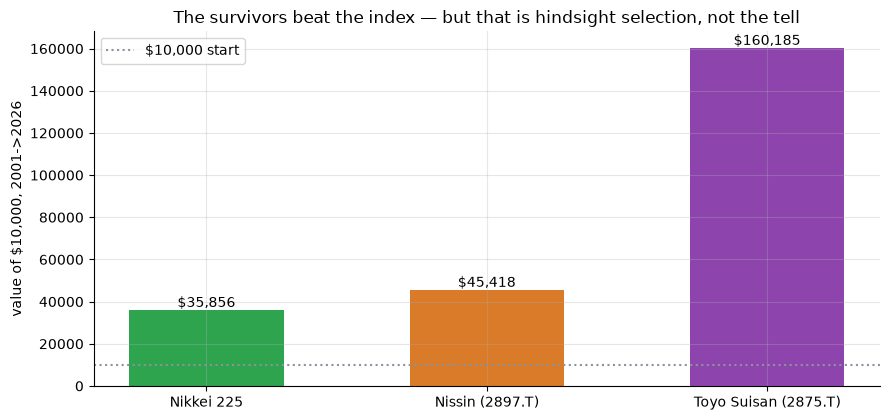

Nikkei: $35,856
Nissin: $45,418
Toyo Suisan: $160,185
WINA lag ~6 mo + NBER lag ~12 mo -> the ramen tell is a double look-ahead


In [7]:
start=10_000.0
if HAVE_PRICES:
    mult=[st.terminal_wealth(PX[t]) for t in ['^N225','2897.T','2875.T']]
else:
    mult=[R['n225_wealth'],R['nis_wealth'],R['toy_wealth']]
ends=[start*m for m in mult]
fig, ax = plt.subplots(figsize=(9.0,4.3))
ax.bar(['Nikkei 225','Nissin (2897.T)','Toyo Suisan (2875.T)'], ends, .55, color=[GREEN, NOOD, '#8e44ad'])
for i,v in enumerate(ends): ax.annotate(f'${v:,.0f}',(i,v),ha='center',va='bottom')
ax.axhline(start, ls=':', c=GREY, label='$10,000 start'); ax.set_ylabel('value of $10,000, 2001->2026'); ax.legend()
ax.set_title('The survivors beat the index — but that is hindsight selection, not the tell')
plt.tight_layout(); plt.show()
for l,v in zip(['Nikkei','Nissin','Toyo Suisan'], ends): print(f'{l}: ${v:,.0f}')
print(f"WINA lag ~{R['wina_lag']} mo + NBER lag ~{R['nber_lag']} mo -> the ramen tell is a double look-ahead")

> 💡 In plain words: there is no implementable version of the *tell*. The leading-indicator claim is false (§4a) and, even if it weren't, the reading arrives half a year late. The buy-and-hold-the-noodle-makers version *did* win — but only because we selected the winners after the fact, and what we bought was low-beta staples beating a uniquely weak index, not a recession forecast. Real edge, wrong claim, and un-front-runnable.

## 7 · Going further

- **US-only demand.** The folklore's anecdote is *American* ramen sales in 2008; swap the global WINA figure for a US Nielsen/IRI series and re-run H₁ — does the tell exist on home turf, or is it also one recession's noise plus COVID?
- **Real-time recession conditioning.** Replace the ex-post NBER flag with a Sahm-rule / term-spread nowcast and test whether *any* staple-demand series leads it with an honest, no-look-ahead entry — the only way the timing question becomes tradable.
- **The staples zoo.** Extend to the lipstick index, discount retail (`DG`, `WMT`), Spam (`HRL`), pooling across many candidate "indices" *with* a White (2000) Reality-Check correction — the honest way to ask whether *any* consumer oddity is a true tell ([docs/references.md](../docs/references.md)).

*The reproducible core is offline and deterministic; prices are real (yfinance, total-return-ish), the WINA series and NBER windows are **cited**. Methods: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*